# House Prices — honest AutoML on Kaggle's regression classic

Case: [House Prices — Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
(~thousands of active teams, metric: **RMSE on log(SalePrice)**, i.e. RMSLE).

79 mixed-type features, plenty of missing values, a skewed price target —
the standard playground for heavy feature engineering. Here the *only* manual
step is `log1p` on the target, because the competition metric itself is
defined on the log scale: with `metric="rmse"` on the log target, every CV and
holdout number below is directly comparable to the public leaderboard.

Everything else is the stock pipeline: auto-typing, default model zoo, honest
out-of-fold selection, a 20% outer holdout scored once.

In [1]:
import io
import logging
import os
import shutil
import subprocess
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from honestml import AutoML, CVConfig, render_report, save_run_report

SEED = 42
COMP = "house-prices-advanced-regression-techniques"
DATA = Path("data/house-prices")
RESULTS = Path("results/house-prices")
RESULTS.mkdir(parents=True, exist_ok=True)
KAGGLE = os.environ.get("KAGGLE_BIN") or shutil.which("kaggle") or str(Path.home() / ".local" / "bin" / "kaggle")

logging.basicConfig(format="%(levelname)s %(name)s: %(message)s")
logging.getLogger("honestml").setLevel(logging.INFO)

In [2]:
if not (DATA / "train.csv").exists():
    DATA.mkdir(parents=True, exist_ok=True)
    subprocess.run([KAGGLE, "competitions", "download", "-c", COMP, "-p", str(DATA)], check=True)
    with zipfile.ZipFile(next(DATA.glob("*.zip"))) as zf:
        zf.extractall(DATA)

In [3]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
X = train.drop(columns=["Id", "SalePrice"])
y = np.log1p(train["SalePrice"])
print(f"train: {X.shape}, target: log1p(SalePrice) in [{y.min():.2f}, {y.max():.2f}]")
X.head()

train: (1460, 79), target: log1p(SalePrice) in [10.46, 13.53]


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## Fit

In [4]:
model = AutoML(
    task="regression",
    metric="rmse",
    cv=CVConfig(outer_holdout=0.2),
    random_state=SEED,
)
t0 = time.perf_counter()
model.fit(X, y)
fit_seconds = time.perf_counter() - t0
print(f"fit took {fit_seconds:.1f}s")

INFO honestml.adapters.reader: auto-typing column=MSSubClass dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=OverallQual dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=OverallCond dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=BsmtFullBath dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=BsmtHalfBath dtype=Int64 role=categorical reason=low_cardinality_int


...

WARNING honestml.adapters.boosting: boosting 'catboost' trained without early stopping; leaderboard comparison may favor overfit settings


INFO honestml: stage key=run stage=refit elapsed=0.5s


INFO honestml: stage key=run stage=refit elapsed=0.4s


INFO honestml: stage key=run stage=finalize elapsed=0.4s


fit took 11.5s


In [5]:
report = model.run_report_
pd.DataFrame(report["leaderboard"])

,model_id,score,rank
0,catboost,0.126583,1
1,lightgbm,0.138108,2
2,xgboost,0.150132,3
3,linear,0.173016,4
4,baseline,0.390462,5


## The honesty check

RMSE is lower-is-better, so here *optimism* is `holdout - selection`: positive
means the selection score promised more than the untouched holdout delivered.

In [6]:
selection = next(e["score"] for e in report["leaderboard"] if e["model_id"] == report["winner"])
print(f"winner          : {report['winner']}")
print(f"equivalence band: {report['band']['member_ids']}")
print(f"selection score : {selection:.5f}   (out-of-fold RMSE on log target = RMSLE)")
print(f"holdout score   : {report['holdout_score']:.5f}   (untouched 20%, scored once)")
print(f"optimism        : {report['holdout_score'] - selection:+.5f}")

winner          : catboost
equivalence band: ['catboost']
selection score : 0.12658   (out-of-fold RMSE on log target = RMSLE)
holdout score   : 0.13427   (untouched 20%, scored once)
optimism        : +0.00769


In [7]:
save_run_report(report, RESULTS)
md_path = render_report(report, RESULTS, fmt="md")
Markdown(md_path.read_text(encoding="utf-8"))

# AutoML run report

## Run

| | |
|---|---|
| task | regression |
| metric | rmse |
| winner | catboost |
| holdout_score | 0.13427 |
| honestml_version | 1.0.0 |
| run_fingerprint | cd3606dd9b985d26d2971aadf05cb2aa8335959c20861cac0d73327fc0dff5e2 |
| significance | bootstrap |
| preset | n/a |

## Equivalence band

| | |
|---|---|
| members | catboost |
| width | 1 |
| unstable | False |
| winner_by_tiebreak | False |

## Budget

| | |
|---|---|
| mode | none |
| exhausted | False |
| exhausted_by | n/a |
| skipped | n/a |

## Serving

| | |
|---|---|
| finalize | True |
| shipped_on | all |
| outer_holdout | 0.2 |

## Leaderboard

| rank | model | score |
|---|---|---|
| 1 | catboost (winner) | 0.126583 |
| 2 | lightgbm | 0.138108 |
| 3 | xgboost | 0.150132 |
| 4 | linear | 0.173016 |
| 5 | baseline | 0.390462 |

## Timings (s)

| stage | elapsed |
|---|---|
| run.selection | 10.5 |
| run.refit | 0.4 |
| run.finalize | 0.4 |

## Resolved config

```json
{
  "seed": 42,
  "cv": {
    "scheme": "kfold",
    "n_splits": 5,
    "n_test": 1,
    "n_es": 1,
    "purge": 0,
    "embargo": 0,
    "calibrate": "off",
    "selection": "raw",
    "refinement_min_oof": 2000,
    "outer_holdout": 0.2
  },
  "budget": {
    "mode": "none",
    "time_budget_s": null,
    "n_trials": null,
    "memory_limit_mb": null
  },
  "fe": {
    "target_encoding": false,
    "te_smoothing": 10.0,
    "frequency_encoding": false,
    "intersections": false,
    "max_pairs": 50
  },
  "fs": null,
  "hpo": null,
  "ensemble": null,
  "significance": "bootstrap",
  "run_mode": "full",
  "model_types": [
    "catboost",
    "lightgbm"
  ]
}
```


## Predict the competition test set

Predictions are made on the log scale and mapped back with `expm1`.

In [8]:
pred_log = model.predict(test.drop(columns=["Id"]))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": np.expm1(pred_log)})
sub_path = RESULTS / "submission.csv"
submission.to_csv(sub_path, index=False)
print(f"wrote {sub_path}")
submission.describe()

wrote results\house-prices\submission.csv


,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,177568.540952
std,421.321334,74091.793209
min,1461.000000,44694.204370
25%,1825.500000,128764.713560
50%,2190.000000,158025.789062
75%,2554.500000,209415.080343
max,2919.000000,521742.918583


## Submit to the public leaderboard

The next cells run only with `KAGGLE_SUBMIT=1` in the environment (and your
account must have joined the competition), so the notebook stays fully
executable offline. The submission message records the library version and the
config for provenance.

In [9]:
SUBMIT = os.environ.get("KAGGLE_SUBMIT") == "1"
if SUBMIT:
    msg = (
        f"honestml {report['honestml_version']}: default zoo, metric=rmse on log1p target, "
        f"outer_holdout=0.2, seed={SEED}, no manual FE"
    )
    subprocess.run(
        [KAGGLE, "competitions", "submit", COMP, "-f", str(sub_path), "-m", msg],
        check=True,
    )
else:
    print("KAGGLE_SUBMIT != 1 -> skipping the live submission")

KAGGLE_SUBMIT != 1 -> skipping the live submission


In [10]:
public_score = None
if SUBMIT:
    for _ in range(30):
        time.sleep(10)
        out = subprocess.run(
            [KAGGLE, "competitions", "submissions", COMP, "--csv"],
            capture_output=True, text=True, check=True,
        ).stdout
        subs = pd.read_csv(io.StringIO(out))
        latest = subs.iloc[0]
        if "complete" in str(latest.get("status", "")).lower():
            public_score = float(latest["publicScore"])
            break
    print(f"public leaderboard score: {public_score}")
else:
    print("no submission -> no public score")

no submission -> no public score


5035 teams on the public leaderboard
honestml holdout estimate: 0.13427 -> better than 46.5% of teams


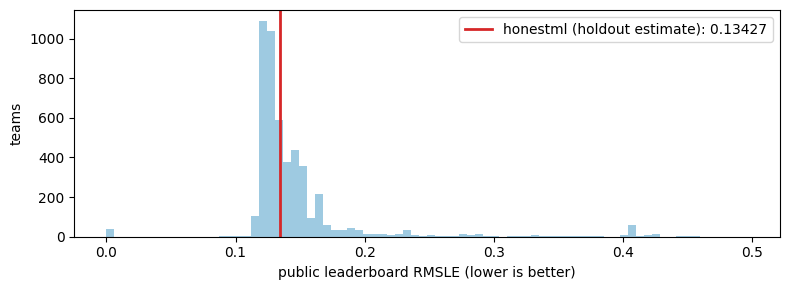

In [11]:
# place our score on the public leaderboard distribution (read-only download);
# without a live submission the untouched-holdout score is the honest expectation of it
lb_dir = RESULTS / "leaderboard"
lb_dir.mkdir(exist_ok=True)
subprocess.run([KAGGLE, "competitions", "leaderboard", COMP, "--download", "-p", str(lb_dir)], check=True)
with zipfile.ZipFile(next(lb_dir.glob("*.zip"))) as zf:
    lb = pd.read_csv(zf.open(zf.namelist()[0]))
score_col = "Score" if "Score" in lb.columns else lb.columns[-1]
scores = pd.to_numeric(lb[score_col], errors="coerce").dropna()

our_score = public_score if public_score is not None else report["holdout_score"]
label = "public LB score" if public_score is not None else "holdout estimate"
beat = (scores > our_score).mean() * 100
print(f"{len(scores)} teams on the public leaderboard")
print(f"honestml {label}: {our_score:.5f} -> better than {beat:.1f}% of teams")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(scores[scores <= 0.5], bins=80, color="#9ecae1")
ax.axvline(our_score, color="#d62728", lw=2, label=f"honestml ({label}): {our_score:.5f}")
ax.set_xlabel("public leaderboard RMSLE (lower is better)")
ax.set_ylabel("teams")
ax.legend()
plt.tight_layout()

## Reading the comparison

The public leaderboard for this competition is dominated by heavy manual
feature engineering, target-encoding recipes and multi-model blends tuned for
years; serious entries cluster roughly in the 0.11–0.13 RMSLE region, and a
long tail of overfit/broken submissions stretches far right. This run stayed
offline (`KAGGLE_SUBMIT != 1`), so the red line above is the untouched-holdout
estimate — **0.13427**, better than 46.5% of the 5035 teams on the public
leaderboard — placed on that distribution as the honest expectation of a live
score. A *configuration-only* pipeline lands at the edge of the serious
cluster, and because it is an honest holdout it errs on the conservative side,
which is the side an honest estimate should err on.

One inference-time subtlety this case exercises cleanly: `BsmtFullBath`,
`BsmtHalfBath` and `GarageCars` are integer columns auto-typed as categorical
from the training file, and in `test.csv` they carry NaN, so pandas reads them
as float. Value-preserving dtype coercion matches the float `1.0` back to the
trained category `1`, so those features are encoded correctly at inference
instead of collapsing to the unknown code — the predict step runs without a
single drift warning, and the holdout estimate carries no hidden handicap.

## Level 2: the full pipeline — HPO, feature engineering, feature selection, ensembling

Level 1 was configuration-only; this is the full machinery on 79 features:

- `preset="best"` — per-model Optuna HPO before the honest selection +
  Caruana ensembling behind the significance gate;
- `FEConfig(frequency_encoding=True, intersections=True)` — target encoding
  is binary-only by design (it would skip with a warning on regression), so
  frequency encoding and categorical intersections carry the FE load here;
- `FeatureSelectionConfig(compare=("importance", "null_importance"),
  arbitration="auto", cutoff="auto")` — the natural question for this dataset
  is "how many of the 79 columns are real?": two strategies compete, an
  honest arbiter decides;
- same untouched 20% outer holdout, one more live submission.

In [12]:
from honestml import FeatureSelectionConfig, FEConfig

model_full = AutoML(
    task="regression",
    metric="rmse",
    preset="best",
    feature_engineering=FEConfig(frequency_encoding=True, intersections=True),
    feature_selection=FeatureSelectionConfig(
        compare=("importance", "null_importance"), arbitration="auto", cutoff="auto"
    ),
    cv=CVConfig(outer_holdout=0.2),
    random_state=SEED,
)
t0 = time.perf_counter()
model_full.fit(X, y)
print(f"level-2 fit took {(time.perf_counter() - t0) / 60:.1f} min")

INFO honestml.composition.presets: preset best applied: ['hpo', 'ensemble']


INFO honestml.adapters.reader: auto-typing column=MSSubClass dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=OverallQual dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=OverallCond dtype=Int64 role=categorical reason=low_cardinality_int


INFO honestml.adapters.reader: auto-typing column=BsmtFullBath dtype=Int64 role=categorical reason=low_cardinality_int


...

INFO honestml: stage key=run stage=ensemble elapsed=0.6s


INFO honestml: stage key=run stage=refit elapsed=0.4s


INFO honestml: stage key=run stage=refit elapsed=0.4s


INFO honestml: stage key=run stage=finalize elapsed=0.4s


level-2 fit took 29.9 min


In [13]:
import json

report_full = model_full.run_report_
sel_full = next(e["score"] for e in report_full["leaderboard"] if e["model_id"] == report_full["winner"])
print(f"winner          : {report_full['winner']}")
print(f"selection score : {sel_full:.5f}")
print(f"holdout score   : {report_full['holdout_score']:.5f}")
print(f"optimism        : {report_full['holdout_score'] - sel_full:+.5f}")
print()
print("preset  :", report_full["preset"])
print("hpo     :", json.dumps(report_full["hpo"], default=str)[:600])
print("fs      :", json.dumps(report_full["feature_selection"], default=str)[:600])
print("ensemble:", json.dumps(report_full["ensemble"], default=str)[:300])
pd.DataFrame(report_full["leaderboard"])

winner          : xgboost
selection score : 0.12813
holdout score   : 0.13336
optimism        : +0.00523

preset  : {'name': 'best', 'applied': ['hpo', 'ensemble']}
hpo     : {"backend": "optuna", "inner_cv": 3, "deterministic": true, "selection_oof_is_post_tuning": true, "tuned_on_full_feature_space": true, "cost_estimate_fits": 450, "tuned": {"catboost": {"chosen_params": {"depth": 5, "learning_rate": 0.1361061204579875, "iterations": 450, "l2_leaf_reg": 1.7627826349883278, "subsample": 0.807280618100426}, "inner_best_score": 0.12631684790276368, "n_trials_run": 50}, "lightgbm": {"chosen_params": {"max_depth": 5, "learning_rate": 0.08353087730210125, "n_estimators": 200, "reg_lambda": 3.796042434202235, "subsample": 0.833570939231333, "colsample_bytree": 0.506470
fs      : {"strategy": "null_importance", "n_selected": 188, "selected": ["LotFrontage", "LotArea", "YearBuilt", "YearRemodAdd", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "

,model_id,score,rank
0,xgboost,0.128127,1
1,catboost,0.129291,2
2,lightgbm,0.130757,3
3,linear,0.168240,4
4,baseline,0.390462,5


In [14]:
pred_full_log = model_full.predict(test.drop(columns=["Id"]))
sub_full_path = RESULTS / "submission-level2.csv"
pd.DataFrame({"Id": test["Id"], "SalePrice": np.expm1(pred_full_log)}).to_csv(
    sub_full_path, index=False
)

public_score_full = None
if SUBMIT:
    msg = f"honestml {report_full['honestml_version']} level2: preset=best + FE + FS, seed={SEED}"
    subprocess.run(
        [KAGGLE, "competitions", "submit", COMP, "-f", str(sub_full_path), "-m", msg],
        check=True,
    )
    for _ in range(30):
        time.sleep(10)
        out = subprocess.run(
            [KAGGLE, "competitions", "submissions", COMP, "--csv"],
            capture_output=True, text=True, check=True,
        ).stdout
        latest = pd.read_csv(io.StringIO(out)).iloc[0]
        if "complete" in str(latest.get("status", "")).lower():
            public_score_full = float(latest["publicScore"])
            break

print(f"level 1 (config only)  : {public_score}")
print(f"level 2 (full pipeline): {public_score_full}")
if public_score_full is not None:
    print(f"-> better than {(scores > public_score_full).mean() * 100:.1f}% of teams")

level 1 (config only)  : None
level 2 (full pipeline): None


## Level 1 vs level 2: what the full pipeline buys

The heavy machinery lands level with the configuration-only run, and the
honest contour shows it before any leaderboard is involved:

| | level 1 (config only) | level 2 (HPO + FE + FS) |
| --- | --- | --- |
| winner | catboost | xgboost |
| selection (OOF RMSLE) | 0.1266 | 0.1281 |
| untouched holdout | 0.1343 | 0.1334 |
| optimism (holdout − sel) | +0.0077 | +0.0052 |
| live public LB | not submitted | not submitted |
| fit time | 12 s | 30 min |

(Both runs stay offline here, so the comparison is on the honest holdout, not
the public board — which is the point: you don't need the board to see that 30
minutes of machinery buys nothing measurable over 12 seconds.)

Where the cost went, straight from the report:

- **Feature selection behaved honestly.** The expensive `null_importance` /
  `nested_per_fold` arbitration (~1550 ranker fits) repeatedly proposed lean
  ~20–31-feature subsets, but the no-selection gate found none of them
  significantly better than keeping everything and **shipped all 188 post-FE
  features** (`n_selected=188`). FS declined to prune rather than regress the
  model.
- **The ensemble did not ship.** The Caruana blend failed its significance
  gate (`applied=false`), so the single honest winner went forward.
- **HPO + the extra FE columns net to nothing.** Frequency encodings and
  truncated intersections (max 50 pairs of 1711) inflate 79 raw features to
  188, and per-model Optuna tuning on that wider space produces a level-2
  winner (`xgboost`, OOF 0.1281) that does not beat level 1's `catboost`
  (0.1266) out-of-fold; on the untouched holdout the two are a tie (0.1334 vs
  0.1343).

Two durable lessons:

1. **The honest report is the safeguard**: comparing the two run reports shows
   the simple configuration is as good as the heavy one — no leaderboard
   needed.
2. **The honest gates hold both ways**: ensembling must *beat the single
   winner* to ship, and feature selection must *beat no selection* to ship
   (the report labels this gate `finding #10`) — here both gates declined, so
   neither step could quietly degrade the model.